**Dataset:** the setup cell selects the completed 262-fact five-shot ensemble when available. Set `DATASET = 'factorial'` to use the original 96-prompt discovery set. The descriptions of the original captures below refer to that factorial dataset.

Five-shot data use the same 262 fact/addend pairs at k=0 and k=20, with native correctness from their saved capture passes. Every target filler token and the separate `Answer`, `:`, assistant marker, and end-of-thinking marker are included; this prompt format has no trailing space. The five demonstrations also change filler length. Cohorts and prompt formats are kept separate.


**Saved square-lens results:** layers 0–41, with separate Answer, colon, and trailing-space positions.


# One-fact addition: top-object square J-Lens

Each panel is prompt position × decoder layer, covering **all zero-based layers 0–41**.
Columns show the fact (`A`), addend (`X`), and sum (`A+X`); the default row shows the
argmax restricted to canonical nonnegative-integer tokens. Set
`SHOW_TOP_TOKEN = True` to also show the full-vocabulary argmax in the top row.
Color is the fraction of examples, with a shared 0–1 scale.

The square J-Lens averages the four residual streams before applying its 4096 × 4096
layer map, followed by the final HF RMSNorm and vocabulary head. Cohorts (`correct`
and `wrong`) use each example's saved native model outcome, not J-Lens predictions.
All displayed positions within an example use the same full-prompt capture.


## Read completed results

Run all cells with the **mech-int (sglang)** kernel, as in `addition_accuracy.ipynb`.
Plots use LaTeX and your configured fonts. The setup cell adds the existing NERSC
TeX Live 2024 binaries to this kernel's PATH if needed; no installation is required. This notebook reads the saved square-lens aggregates from completed run
`58185137`, which contains filler lengths **0 and 20**, with 96 examples each.
Change `FILLER_LENGTH` below to select either length. Change `RUN` only to another
completed comparison with full answer-prefix coverage and all square layers.

No model load, projection, fitting, or compute allocation is needed to view these results.
The saved summary uses exact single-token targets and lowest-token-ID argmax tie-breaking.
Both argmax scopes were computed from the complete vocabulary readout, including every
canonical integer token. Historical k=5/k=10 results lack Answer/colon positions and are
available separately through `one_fact_jlens_comparison.ipynb` by selecting a historical run.


In [1]:
from pathlib import Path
import importlib
import os
import shutil
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

# Match addition_accuracy's mech-int (sglang) kernel, including when rerunning
# in an already-open NERSC Python kernel that did not inherit the TeX Live path.
TEXLIVE_BIN = Path('/global/common/software/nersc9/texlive/2024/bin/x86_64-linux')
# Use one complete TeX installation, including Matplotlib's font lookup tools.
if TEXLIVE_BIN.is_dir():
    tex_path = [entry for entry in os.environ.get('PATH', '').split(os.pathsep)
                if entry != str(TEXLIVE_BIN)]
    os.environ['PATH'] = os.pathsep.join([str(TEXLIVE_BIN), *tex_path])
missing_tex = [name for name in ('latex', 'dvipng', 'kpsewhich')
               if shutil.which(name) is None]
if missing_tex:
    raise RuntimeError(f"Missing LaTeX tools: {missing_tex}. Select the mech-int (sglang) "
                       "kernel, or load texlive/2024 before starting Jupyter.")
# Resolve fonts through this TeX installation directly. Matplotlib's persistent
# LuaTeX helper can inherit a different TeX search configuration from the kernel.
from functools import lru_cache
from unittest.mock import patch
import io
import subprocess
import matplotlib.dviread as dviread
from IPython.display import Image, display

KPSEWHICH = str(TEXLIVE_BIN / 'kpsewhich') if TEXLIVE_BIN.is_dir() else shutil.which('kpsewhich')

@lru_cache(maxsize=256)
def notebook_tex_file(filename):
    filename = os.fsdecode(filename)
    # Keep kernel-specific TeX search overrides out of this font lookup.
    lookup_env = {key: value for key, value in os.environ.items()
                  if not key.startswith('TEX') and key not in
                  {'TFMFONTS', 'VFFONTS', 'T1FONTS', 'ENCFONTS', 'FONTCONFIG_FILE'}}
    result = subprocess.run([KPSEWHICH, filename], env=lookup_env,
                            capture_output=True, text=True, timeout=10)
    found = result.stdout.strip()
    if result.returncode != 0 or not found or not Path(found).is_file():
        raise FileNotFoundError(f'{KPSEWHICH} could not resolve {filename!r}: '
                                f'{result.stderr.strip()}')
    return found

cmr_font = notebook_tex_file('cmr10.tfm')
print(f"TeX lookup: direct kpsewhich; Computer Modern: {cmr_font}")
print(f"Python: {sys.executable}")

ROOT = next((path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (path / 'filler/dsv4').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the repository root or notebooks directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import filler.dsv4.top_object_heatmap as heatmap_tools
importlib.reload(heatmap_tools)
from filler.dsv4.jlens_comparison import load_completed
OBJECTS = heatmap_tools.OBJECTS

from filler.dsv4.five_shot_jlens_heatmap import load_completed as load_five_shot, heatmap_stats
FIVE_SHOT_COMPLETE = ROOT / 'runs/deepseek-v4-flash/five-shot-jlens-heatmap/COMPLETE.json'
DATASET = 'five_shot' if FIVE_SHOT_COMPLETE.is_file() else 'factorial'  # Choose 'five_shot' or 'factorial'.
FIVE_SHOT_RUN = None  # Optional explicit completed scoring runtime.
VALIDATED_EXPORT = False  # Used only by the allocation-owned notebook validation.
if DATASET not in {'five_shot', 'factorial'}:
    raise ValueError("DATASET must be 'five_shot' or 'factorial'")
DATASET_LABEL = 'five-shot, 262 facts' if DATASET == 'five_shot' else 'factorial discovery'
FILLER_LENGTH = 20
SHOW_GRID = True
SHOW_TOP_TOKEN = False
if DATASET == 'five_shot':
    RUN = FIVE_SHOT_RUN or Path(json.loads(FIVE_SHOT_COMPLETE.read_text())['runtime'])
    completion, square_summary = load_five_shot(RUN, validated=VALIDATED_EXPORT)
else:
    RUN = ROOT / 'runs/deepseek-v4-flash/jlens-comparison/58185137'
    _, square_summary = load_completed(RUN)
    completion = json.loads((RUN / 'COMPLETE.json').read_text())
    if completion.get('complete_answer_prefix') is not True:
        raise ValueError('Select a completed run with full answer-prefix coverage.')
print(f'Dataset: {DATASET_LABEL}')
if not square_summary:
    raise ValueError('The completed run has no square-lens summary.')
available_filler_lengths = sorted({row['filler_length'] for row in square_summary})
print(f'Results: {RUN}')
print(f'Square J-Lens; filler lengths: {available_filler_lengths}; layers: 0–41')


def get_stats(filler_length, cohort):
    if DATASET == 'five_shot':
        return heatmap_stats(square_summary, completion, filler_length, cohort)
    if cohort not in {'all', 'correct', 'wrong'}:
        raise ValueError("cohort must be 'all', 'correct', or 'wrong'")
    selected = [row for row in square_summary
                if row['filler_length'] == filler_length and row['cohort'] == cohort]
    if not selected:
        raise ValueError(f'No {cohort} data for filler length {filler_length}; '
                         f'available lengths: {available_filler_lengths}')
    positions = ['last_question', *[f'filler_{i}' for i in range(filler_length)],
                 *heatmap_tools.ANSWER_POSITIONS]
    layers = list(range(42))
    indexed = {(row['position_label'], row['layer'], row['target_name']): row
               for row in selected}
    expected = {(p, layer, obj) for p in positions for layer in layers for obj in OBJECTS}
    if len(indexed) != len(selected) or set(indexed) != expected:
        raise ValueError('Expected one square summary per target/position/layer, '
                         'including layers 0–41 and the full answer prefix.')
    expected_n = completion['cohort_counts'][f'{filler_length}/{cohort}']
    if expected_n <= 0 or any(row['n'] != expected_n for row in selected):
        raise ValueError('Summary denominators disagree with the completed cohort counts.')
    rates = {scope: {obj: [[indexed[p, layer, obj][metric] for layer in layers]
                          for p in positions] for obj in OBJECTS}
             for scope, metric in (('all', 'square_top1'), ('numeric', 'square_numeric_top1'))}
    for values in rates.values():
        for matrix in values.values():
            values_array = np.asarray(matrix)
            if not np.all(np.isfinite(values_array) & (values_array >= 0) & (values_array <= 1)):
                raise ValueError('Expected finite square-lens rates between zero and one.')
    return {'filler_length': filler_length, 'cohort': cohort, 'positions': positions,
            'layers': layers, 'rates': rates,
            'example_counts': {f'{p}:{layer}': expected_n for p in positions for layer in layers}}

# Check every available cohort before plotting any of them.
for length in available_filler_lengths:
    for cohort in ('all', 'correct', 'wrong'):
        get_stats(length, cohort)


TeX lookup: direct kpsewhich; Computer Modern: /global/common/software/nersc9/texlive/2024-17c650b50c05ee823c6093081103ed0ab76a21df/texmf-dist/fonts/tfm/public/cm/cmr10.tfm
Python: /global/common/software/nersc/pe/conda-envs/26.8.0/python-3.13/nersc-python/bin/python
Dataset: five-shot, 262 facts
Results: /pscratch/sd/m/marocco/sandbox/mech_int/runs/deepseek-v4-flash/five-shot-jlens-heatmap/runtimes/58218428
Square J-Lens; filler lengths: [0, 20]; layers: 0–41


In [2]:
@plt.rc_context({'text.usetex': True, 'axes.labelsize': 16,
                 'xtick.labelsize': 14, 'ytick.labelsize': 14})
def show_heatmap(filler_length=20, cohort='all', show_grid=True, show_top_token=False):
    if cohort not in {'all', 'correct', 'wrong'}:
        raise ValueError("cohort must be 'all', 'correct', or 'wrong'")
    stats = get_stats(filler_length, cohort)
    positions, layers = stats['positions'], stats['layers']
    labelled_fillers = {f'filler_{i}' for i in (0, 3, 7, 11, 15, 19)}
    position_labels = [
        heatmap_tools.position_tick_label(p).replace('_', r'\_')
        if not p.startswith('filler_') or p in labelled_fillers else ''
        for p in positions
    ]
    rows = [('numeric', 'Top numerical token')]
    if show_top_token:
        rows.insert(0, ('all', 'Top token'))
    row_count = len(rows)
    fig, axes = plt.subplots(
        row_count, 3, figsize=(16, row_count * max(4, 0.25 * len(positions))),
        sharex=True, sharey=True, squeeze=False, constrained_layout=True,
    )
    for i, (scope, row_title) in enumerate(rows):
        for j, (obj, title) in enumerate(zip(OBJECTS, ('Fact (A)', 'Addend (X)', 'Sum (A+X)'))):
            ax = axes[i, j]
            image = ax.imshow(np.asarray(stats['rates'][scope][obj]), origin='lower', aspect='auto',
                              interpolation='nearest', cmap='magma', vmin=0, vmax=1)
            if show_grid:
                # Place grid lines at cell boundaries.
                ax.set_xticks(np.arange(len(layers) + 1) - 0.5, minor=True)
                ax.set_yticks(np.arange(len(positions) + 1) - 0.5, minor=True)
                # ax.grid(
                #     which='minor', color='white', linestyle=':',
                #     linewidth=0.6, alpha=0.8
                #)
                ax.tick_params(which='minor', bottom=False, left=False)
            ax.set_title(title)
            if j == 0:
                ax.set_ylabel(f'{row_title}\nprompt position')
                ax.set_yticks(range(len(positions)), position_labels)
            if i == row_count - 1:
                ax.set_xlabel('decoder layer')
                ticks = sorted(set(range(0, len(layers), 6)) | {len(layers) - 1})
                ax.set_xticks(ticks, [layers[k] for k in ticks])
    counts = sorted(set(stats['example_counts'].values()))
    sample_size = str(counts[0]) if len(counts) == 1 else f'{min(counts)}–{max(counts)}'
    fig.suptitle(f'One-fact addition J-Lens - {DATASET_LABEL} - {cohort} examples '
                 f'(n={sample_size}, filler length {filler_length})')
    fig.colorbar(image, ax=axes, label='fraction of examples', shrink=0.9)
    # Finish rendering while the direct font resolver is active. Display PNG
    # bytes so Jupyter does not defer a second TeX render until after this scope.
    try:
        png = io.BytesIO()
        with patch.object(dviread, 'find_tex_file', notebook_tex_file):
            fig.savefig(png, format='png', dpi=fig.dpi, bbox_inches='tight')
        display(Image(data=png.getvalue()))
    finally:
        plt.close(fig)
    return stats



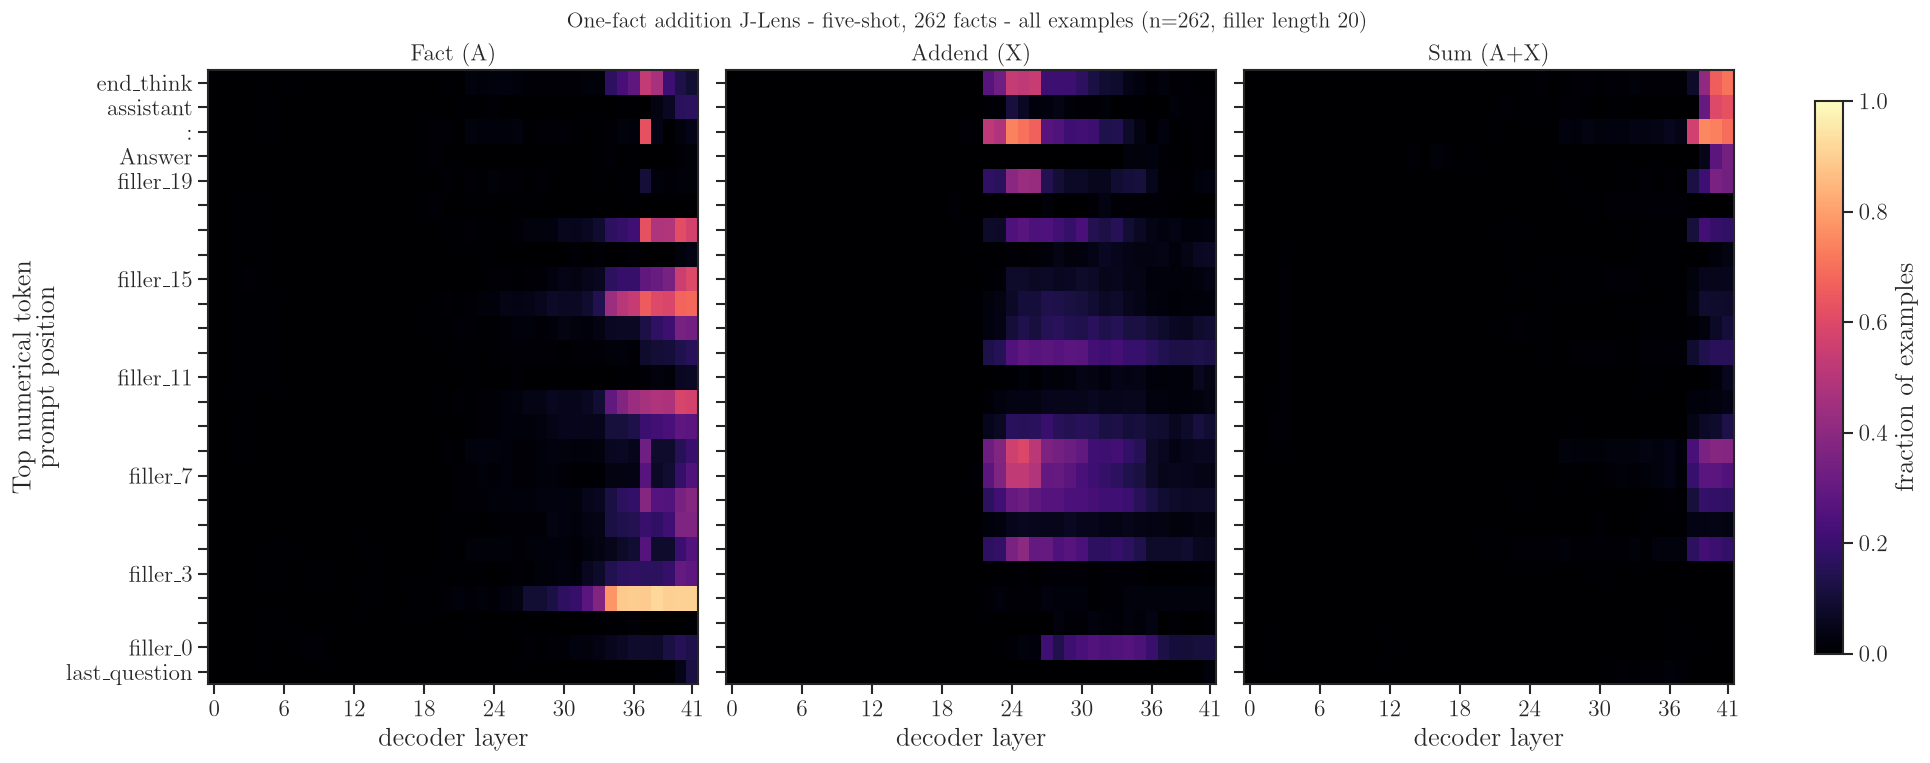

In [3]:
stats_all = show_heatmap(FILLER_LENGTH, 'all', show_grid=SHOW_GRID, show_top_token=SHOW_TOP_TOKEN)


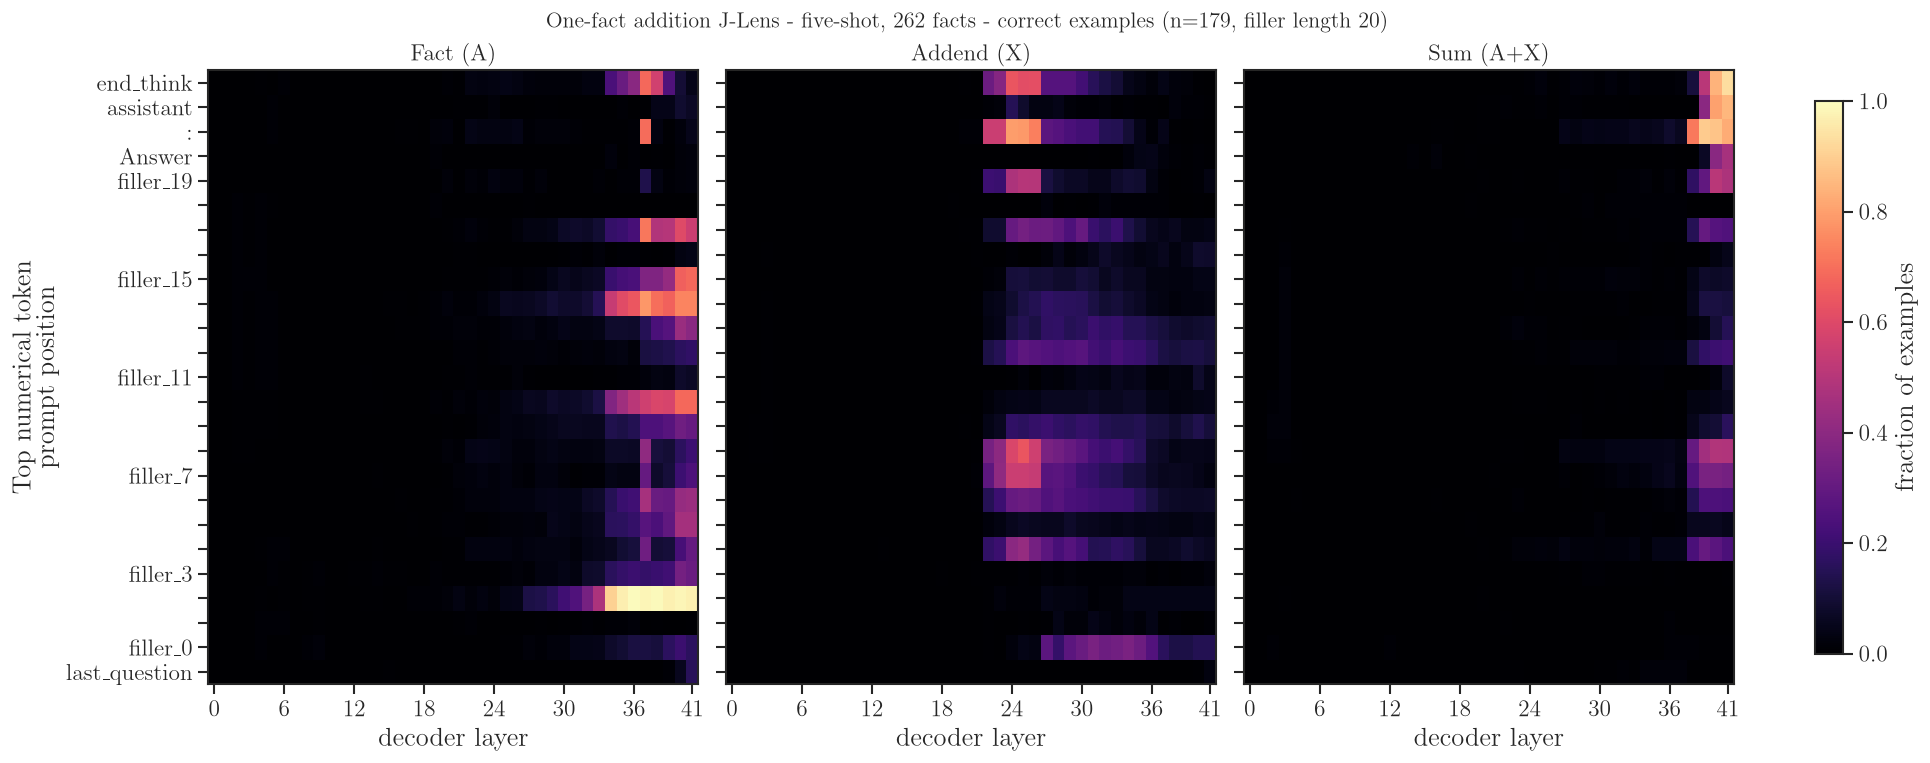

In [4]:
stats_correct = show_heatmap(FILLER_LENGTH, 'correct', show_grid=SHOW_GRID, show_top_token=SHOW_TOP_TOKEN)


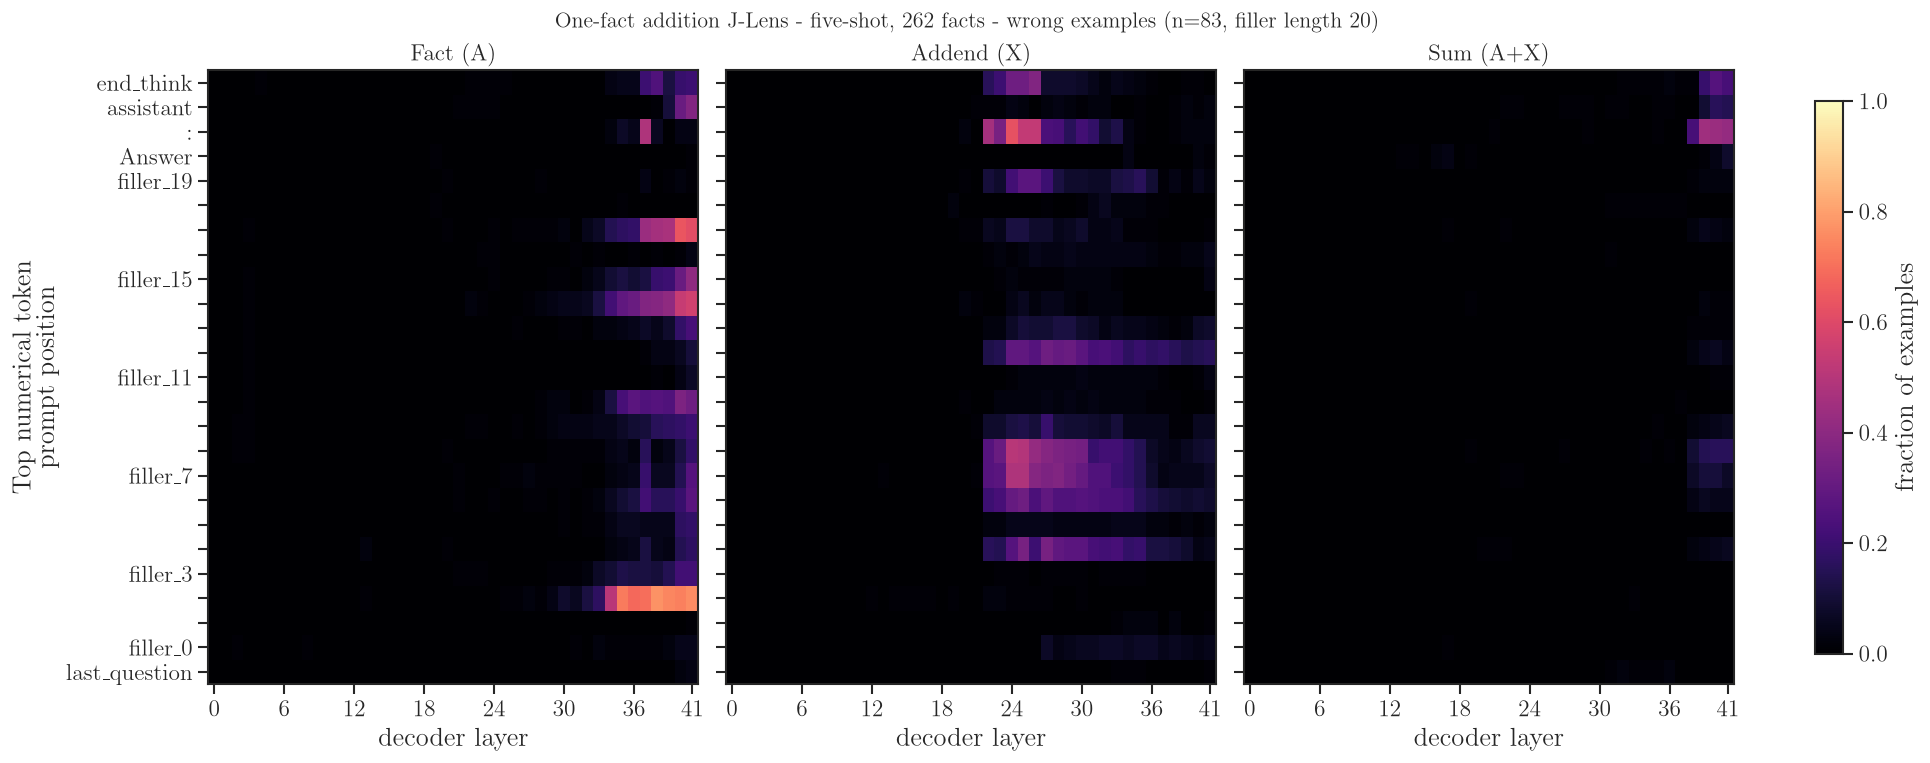

In [5]:
stats_wrong = show_heatmap(FILLER_LENGTH, 'wrong', show_grid=SHOW_GRID, show_top_token=SHOW_TOP_TOKEN)


Use any available filler length and `cohort='all'`, `'correct'`, or `'wrong'` in `show_heatmap`. Set `SHOW_TOP_TOKEN = True` in the setup cell (or pass `show_top_token=True`) to restore both rows; the default shows only the top numerical token. Set `show_grid=False` to hide the dotted cell boundaries. Each figure reports its cohort size; compare the wrong cohort with its smaller denominator in mind.


In [6]:
# Exact plotted sum rates (position × decoder layer (0–41)), and cell denominators.
sum_numeric_rates = np.asarray(stats_all['rates']['numeric']['A+X'])
sum_numeric_rates.shape, sum_numeric_rates.min(), sum_numeric_rates.max(), stats_all['example_counts']


((25, 42),
 np.float64(0.0),
 np.float64(0.7519083969465649),
 {'last_question:0': 262,
  'last_question:1': 262,
  'last_question:2': 262,
  'last_question:3': 262,
  'last_question:4': 262,
  'last_question:5': 262,
  'last_question:6': 262,
  'last_question:7': 262,
  'last_question:8': 262,
  'last_question:9': 262,
  'last_question:10': 262,
  'last_question:11': 262,
  'last_question:12': 262,
  'last_question:13': 262,
  'last_question:14': 262,
  'last_question:15': 262,
  'last_question:16': 262,
  'last_question:17': 262,
  'last_question:18': 262,
  'last_question:19': 262,
  'last_question:20': 262,
  'last_question:21': 262,
  'last_question:22': 262,
  'last_question:23': 262,
  'last_question:24': 262,
  'last_question:25': 262,
  'last_question:26': 262,
  'last_question:27': 262,
  'last_question:28': 262,
  'last_question:29': 262,
  'last_question:30': 262,
  'last_question:31': 262,
  'last_question:32': 262,
  'last_question:33': 262,
  'last_question:34': 262,
  '

In [7]:
# Optional export: uncomment to save the exact aggregates in notebooks/plots.
# output_dir = ROOT / 'notebooks/plots'
# output_dir.mkdir(exist_ok=True)
# for stats in (stats_all, stats_correct, stats_wrong):
#     path = output_dir / f"top_object_square_jlens_k{stats['filler_length']}_{stats['cohort']}.json"
#     path.write_text(json.dumps(stats, indent=2, sort_keys=True) + '\n')


Readout implementation and compatibility results: [`DEEPSEEK_V4_JLENS.md`](../DEEPSEEK_V4_JLENS.md). Preparation details and this notebook's validation record: [`LOGIT_LENS_TOP_OBJECT_HEATMAP.md`](../LOGIT_LENS_TOP_OBJECT_HEATMAP.md).


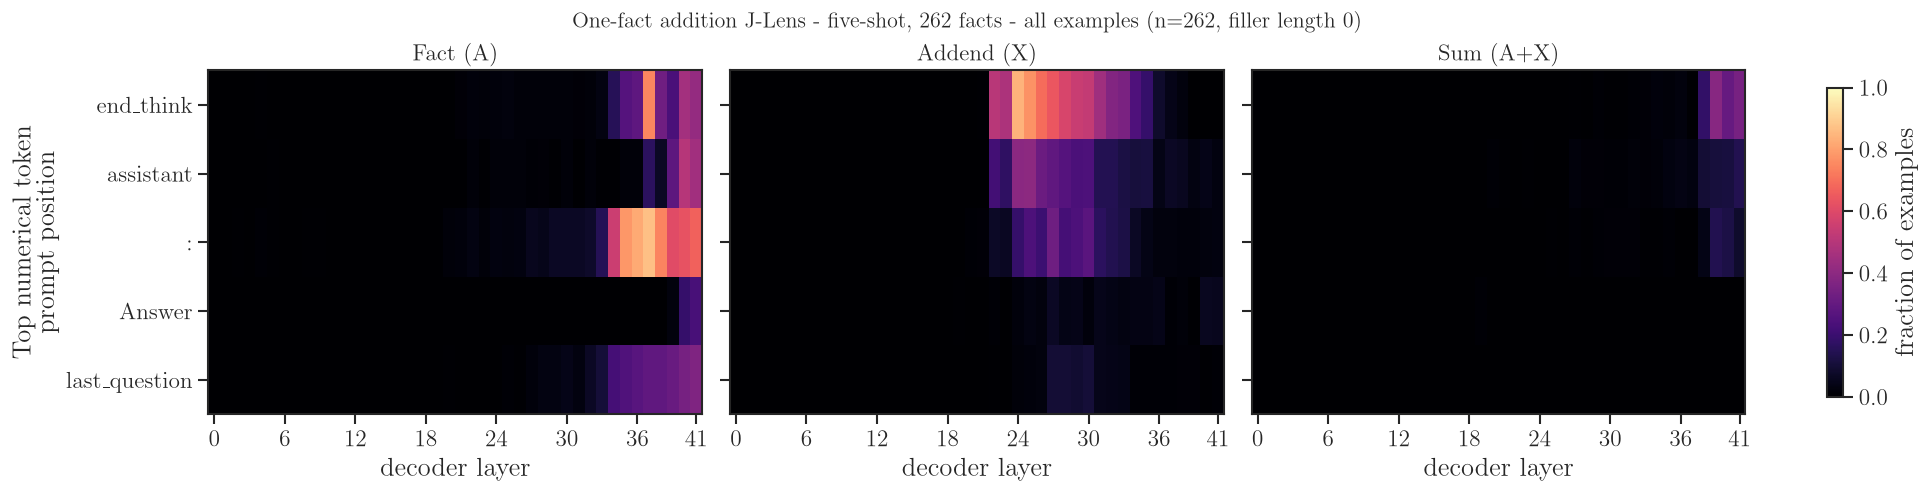

In [8]:
if DATASET == 'five_shot':
    stats_k0_all = show_heatmap(0, 'all', show_grid=SHOW_GRID, show_top_token=SHOW_TOP_TOKEN)


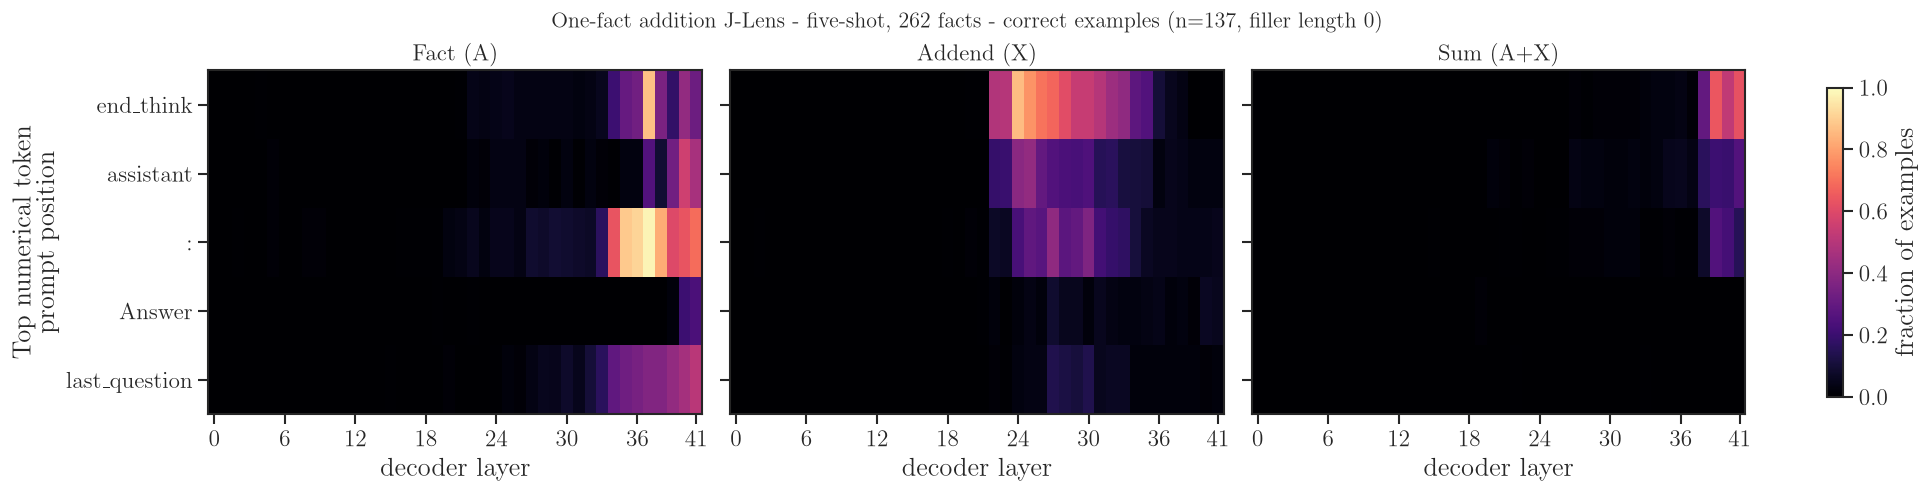

In [9]:
if DATASET == 'five_shot':
    stats_k0_correct = show_heatmap(0, 'correct', show_grid=SHOW_GRID, show_top_token=SHOW_TOP_TOKEN)


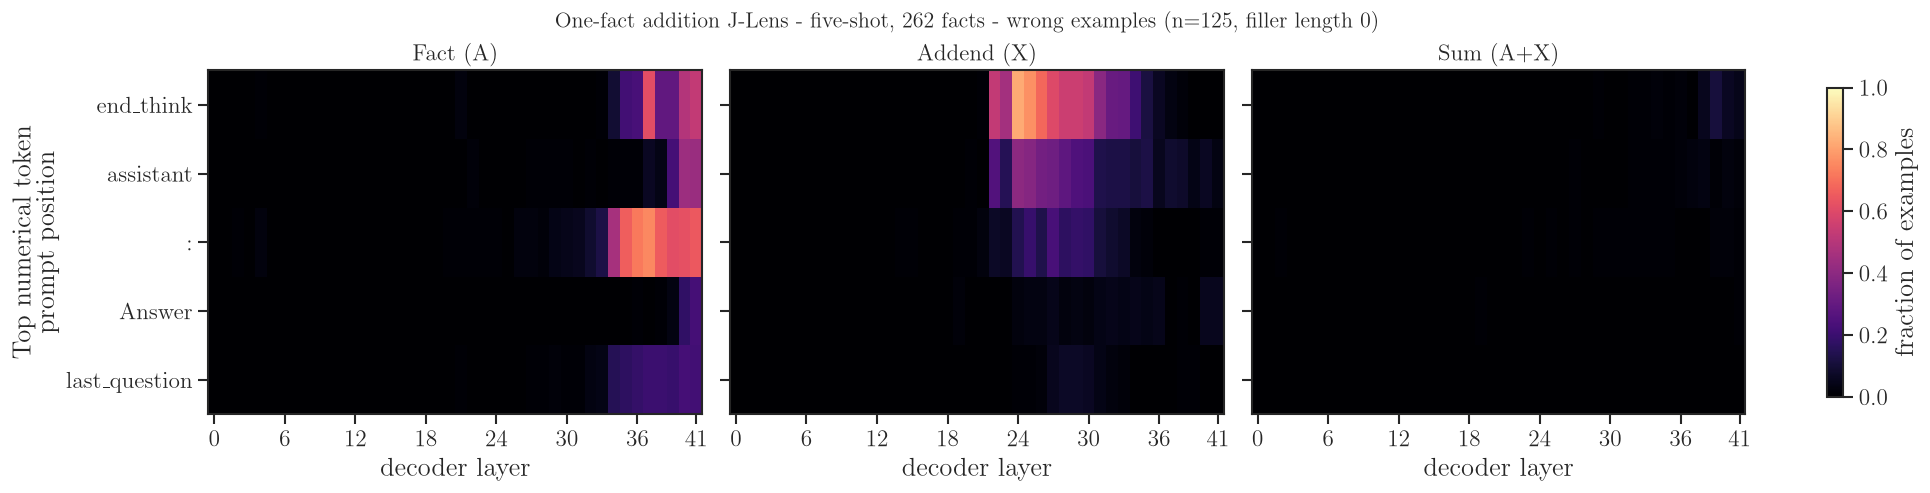

In [10]:
if DATASET == 'five_shot':
    stats_k0_wrong = show_heatmap(0, 'wrong', show_grid=SHOW_GRID, show_top_token=SHOW_TOP_TOKEN)
